<a href="https://colab.research.google.com/github/mstya/yolo-cat-fight-detector/blob/main/CatFightDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics -q
!pip install gdown -q
!pip install mlflow -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!nvidia-smi

Sat Sep 12 13:00:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!gdown 1kqk5LxQemzdLIThoFuCHMWYejCz1mOzw
!unzip -o -q 'cat-fight-dataset-v2.zip'

Downloading...
From (original): https://drive.google.com/uc?id=1kqk5LxQemzdLIThoFuCHMWYejCz1mOzw
From (redirected): https://drive.google.com/uc?id=1kqk5LxQemzdLIThoFuCHMWYejCz1mOzw&confirm=t&uuid=e54bd472-0f36-459f-8774-069056f32780
To: /content/cat-fight-dataset-v2.zip
100% 1.99G/1.99G [00:21<00:00, 91.7MB/s]


In [6]:
!curl -o /content/data.yaml https://raw.githubusercontent.com/mstya/yolo-cat-fight-detector/refs/heads/main/data.yaml

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   125  100   125    0     0    592      0 --:--:-- --:--:-- --:--:--   595


In [9]:
import os
os.environ['MLFLOW_TRACKING_URI'] = 'file:/content/drive/MyDrive/mlflow-runs'
os.environ['MLFLOW_EXPERIMENT_NAME'] = 'cat-fight-detector'
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

In [10]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=60 imgsz=640 name=cat-fight-detector

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cat-fight-detector-2, nbs=64, nms=None, opset=None, optimi

Mounted at /content/drive


In [11]:
!yolo detect predict model=runs/detect/cat-fight-detector-2/weights/best.pt source=/content/cat-fight-dataset-v2/images/Test save=True name=cat-fight-detector

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs

image 1/51 /content/cat-fight-dataset-v2/images/Test/3_img001.png: 640x384 1 cat_white, 10.8ms
image 2/51 /content/cat-fight-dataset-v2/images/Test/3_img002.png: 640x384 1 cat_white, 10.9ms
image 3/51 /content/cat-fight-dataset-v2/images/Test/3_img003.png: 640x384 1 cat_white, 13.0ms
image 4/51 /content/cat-fight-dataset-v2/images/Test/3_img004.png: 640x384 1 cat_white, 1 cat_grey, 12.4ms
image 5/51 /content/cat-fight-dataset-v2/images/Test/3_img005.png: 640x384 1 cat_white, 1 cat_grey, 10.8ms
image 6/51 /content/cat-fight-dataset-v2/images/Test/3_img006.png: 640x384 1 cat_white, 10.8ms
image 7/51 /content/cat-fight-dataset-v2/images/Test/3_img007.png: 640x384 1 cat_white, 1 cat_grey, 10.8ms
image 8/51 /content/cat-fight-dataset-v2/images/Test/3_img008.png: 640x384 1 cat_white, 1 cat_grey, 10.8ms
image 9/51 /content/cat

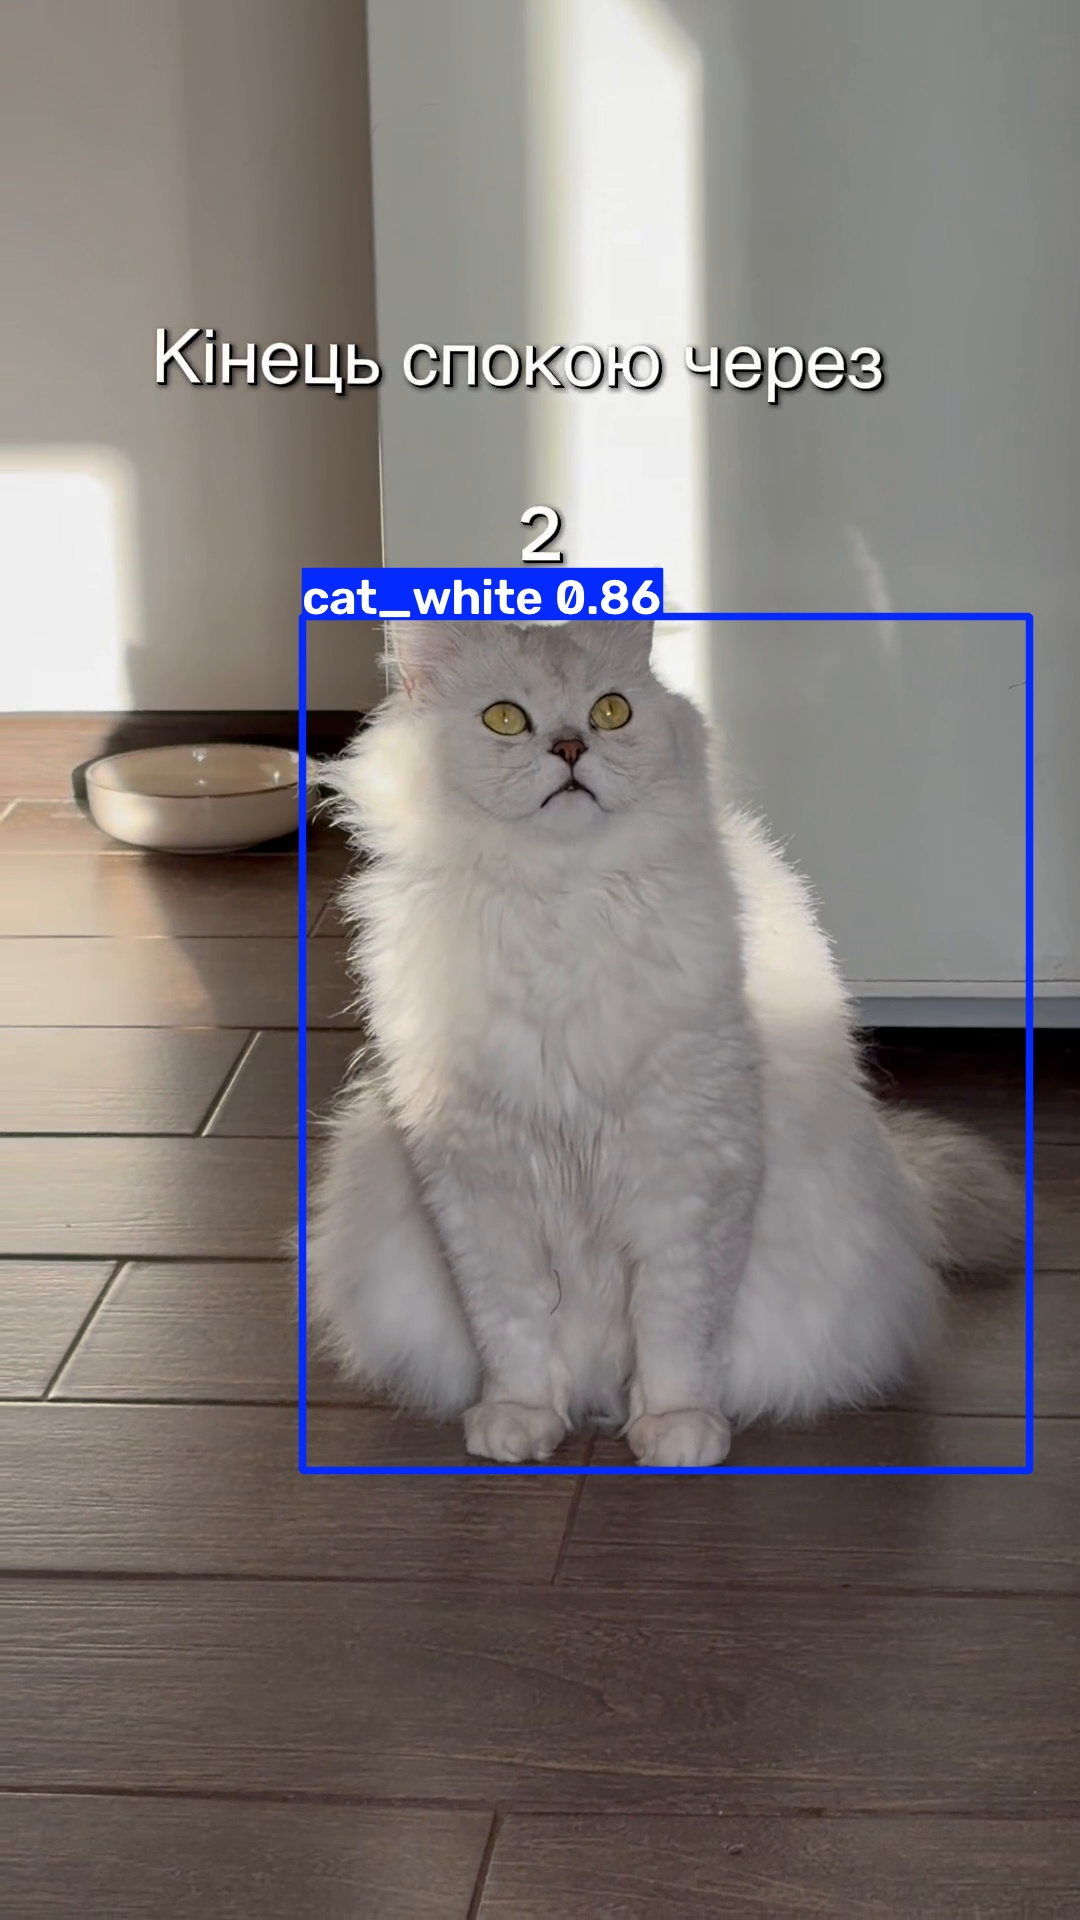

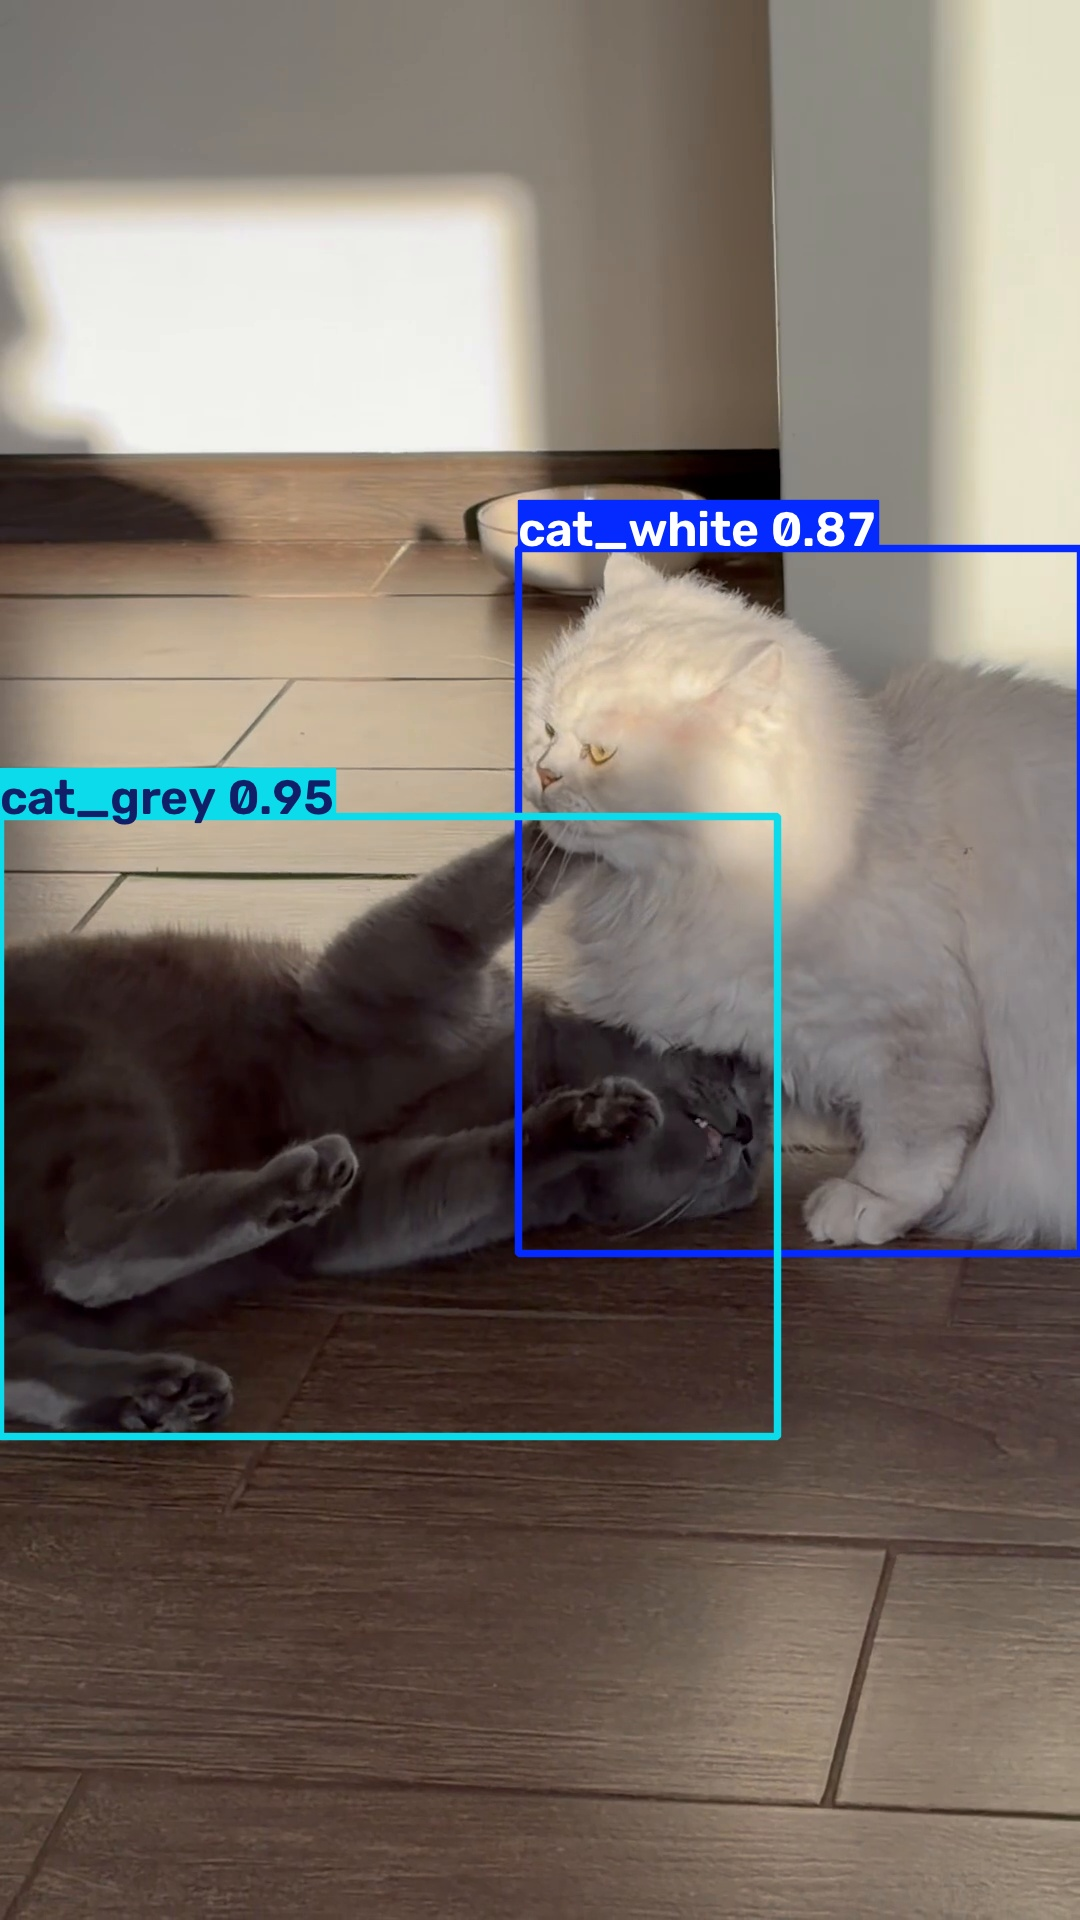

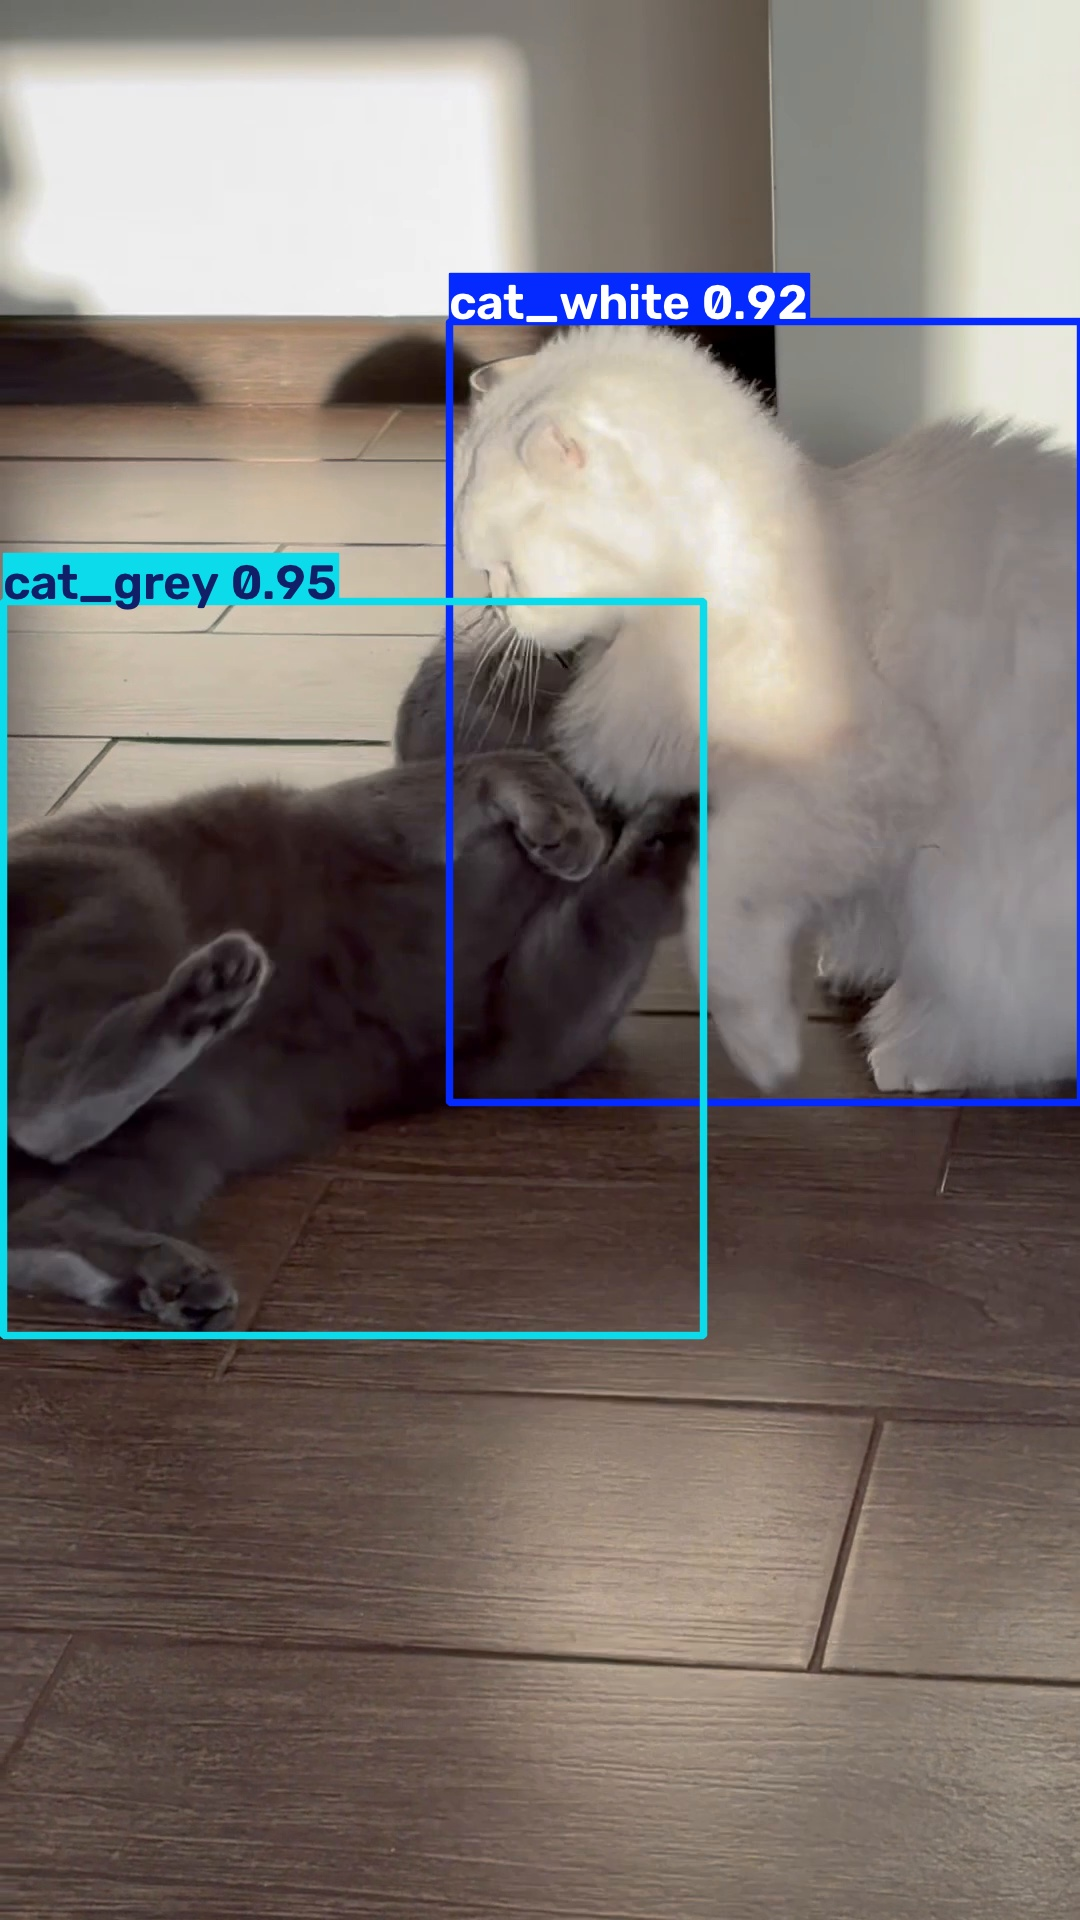

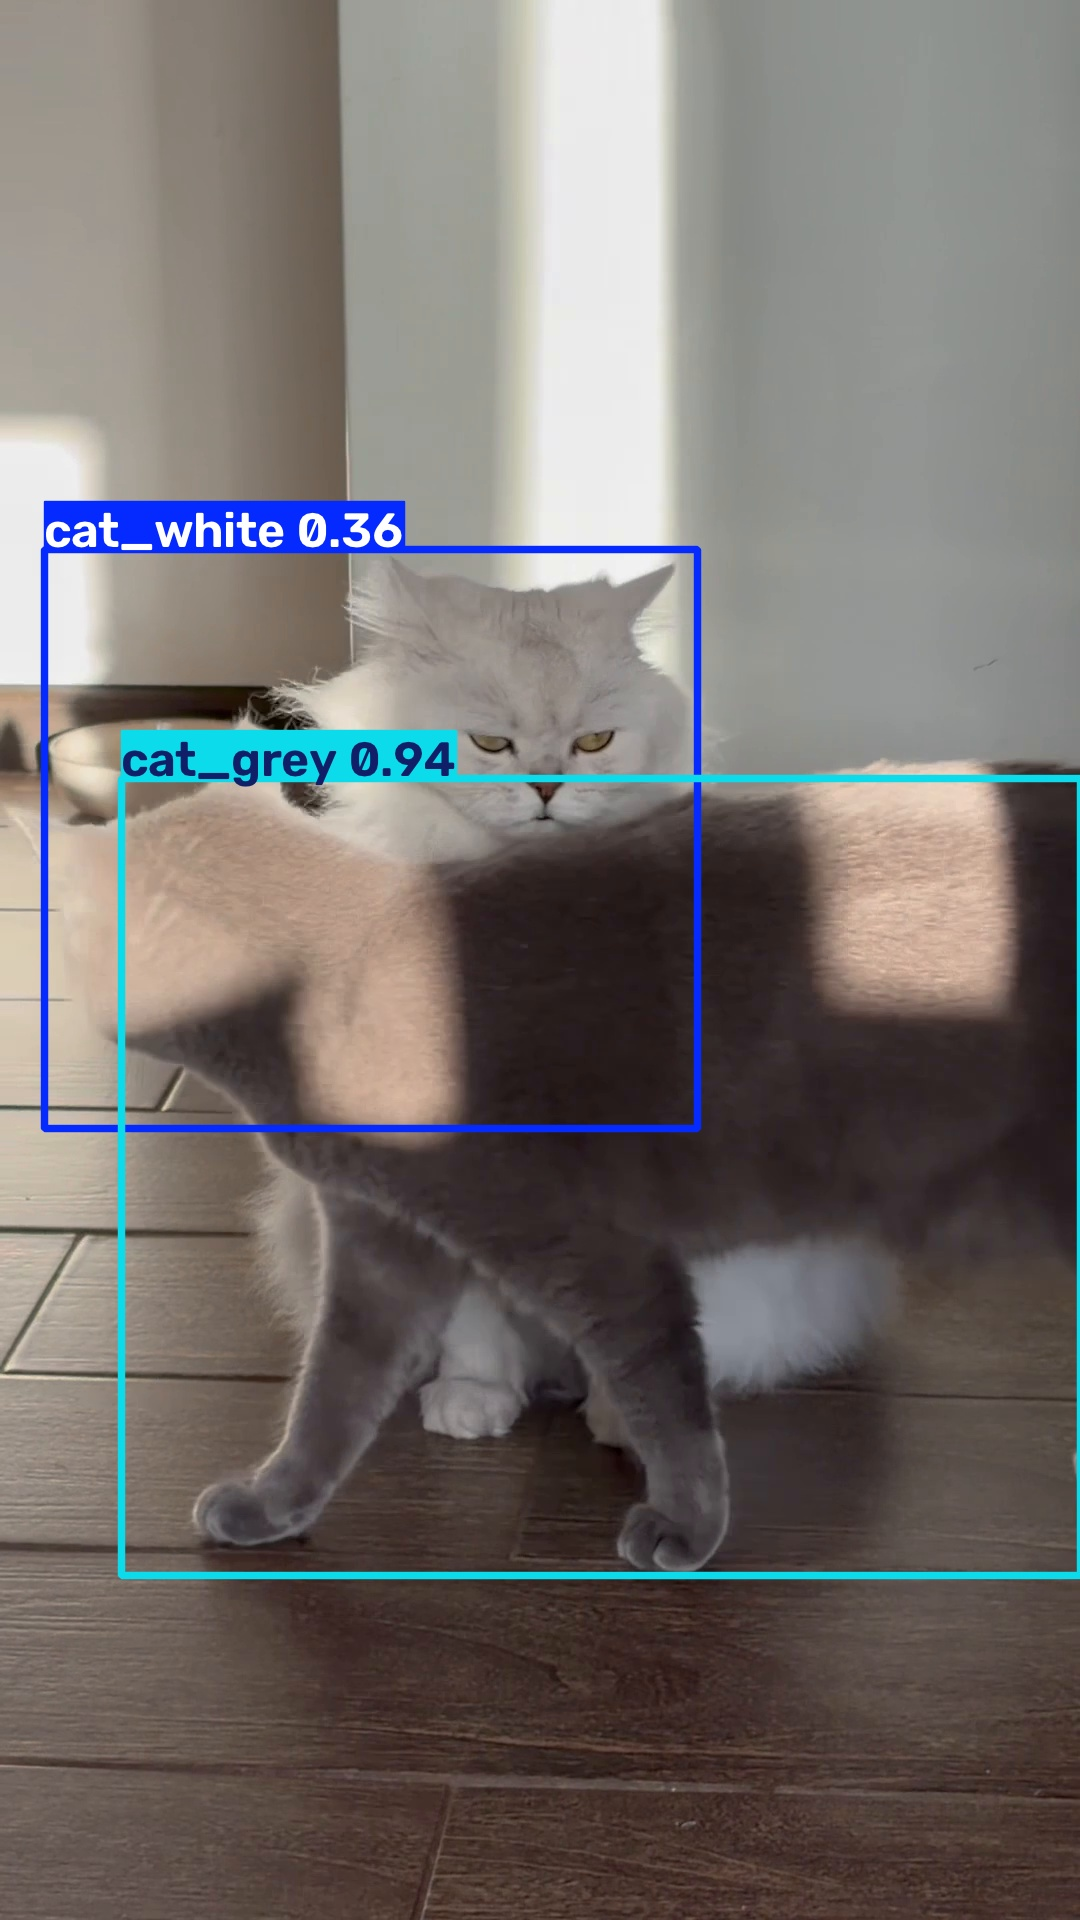

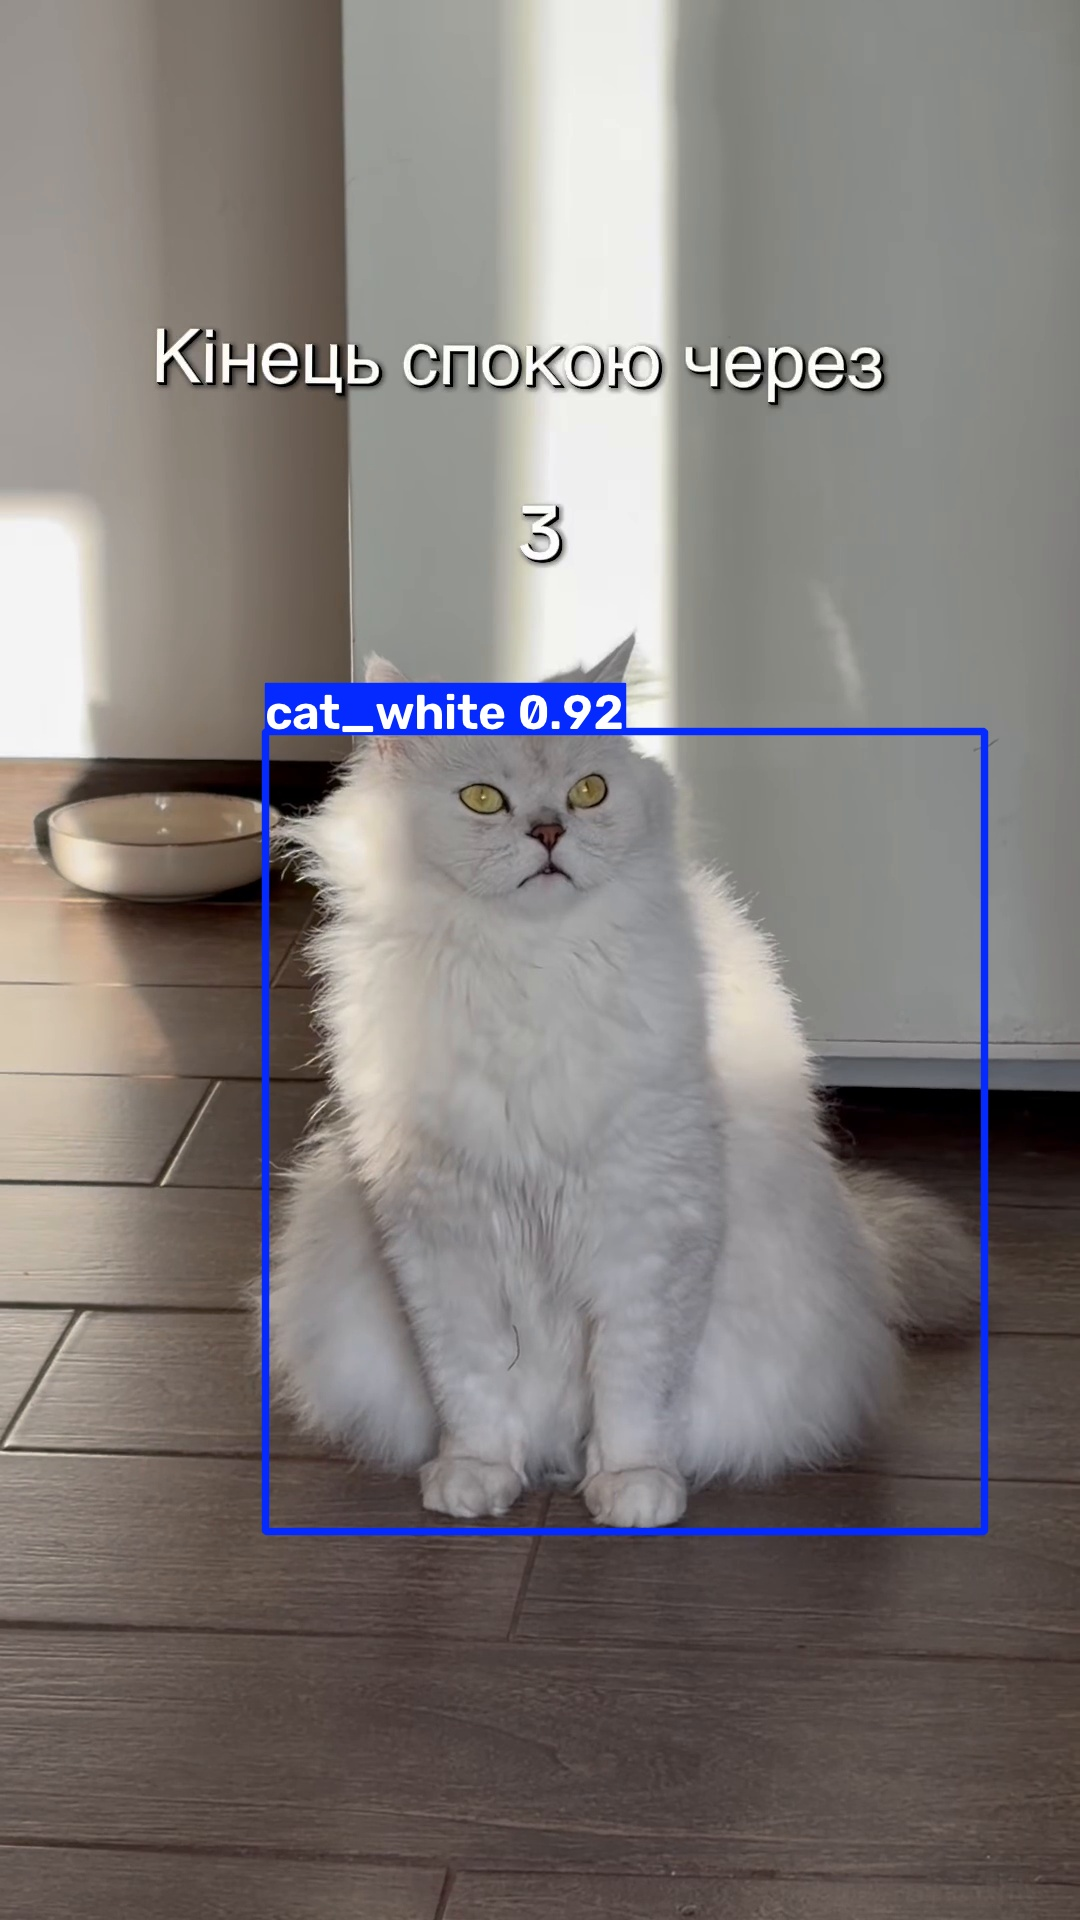

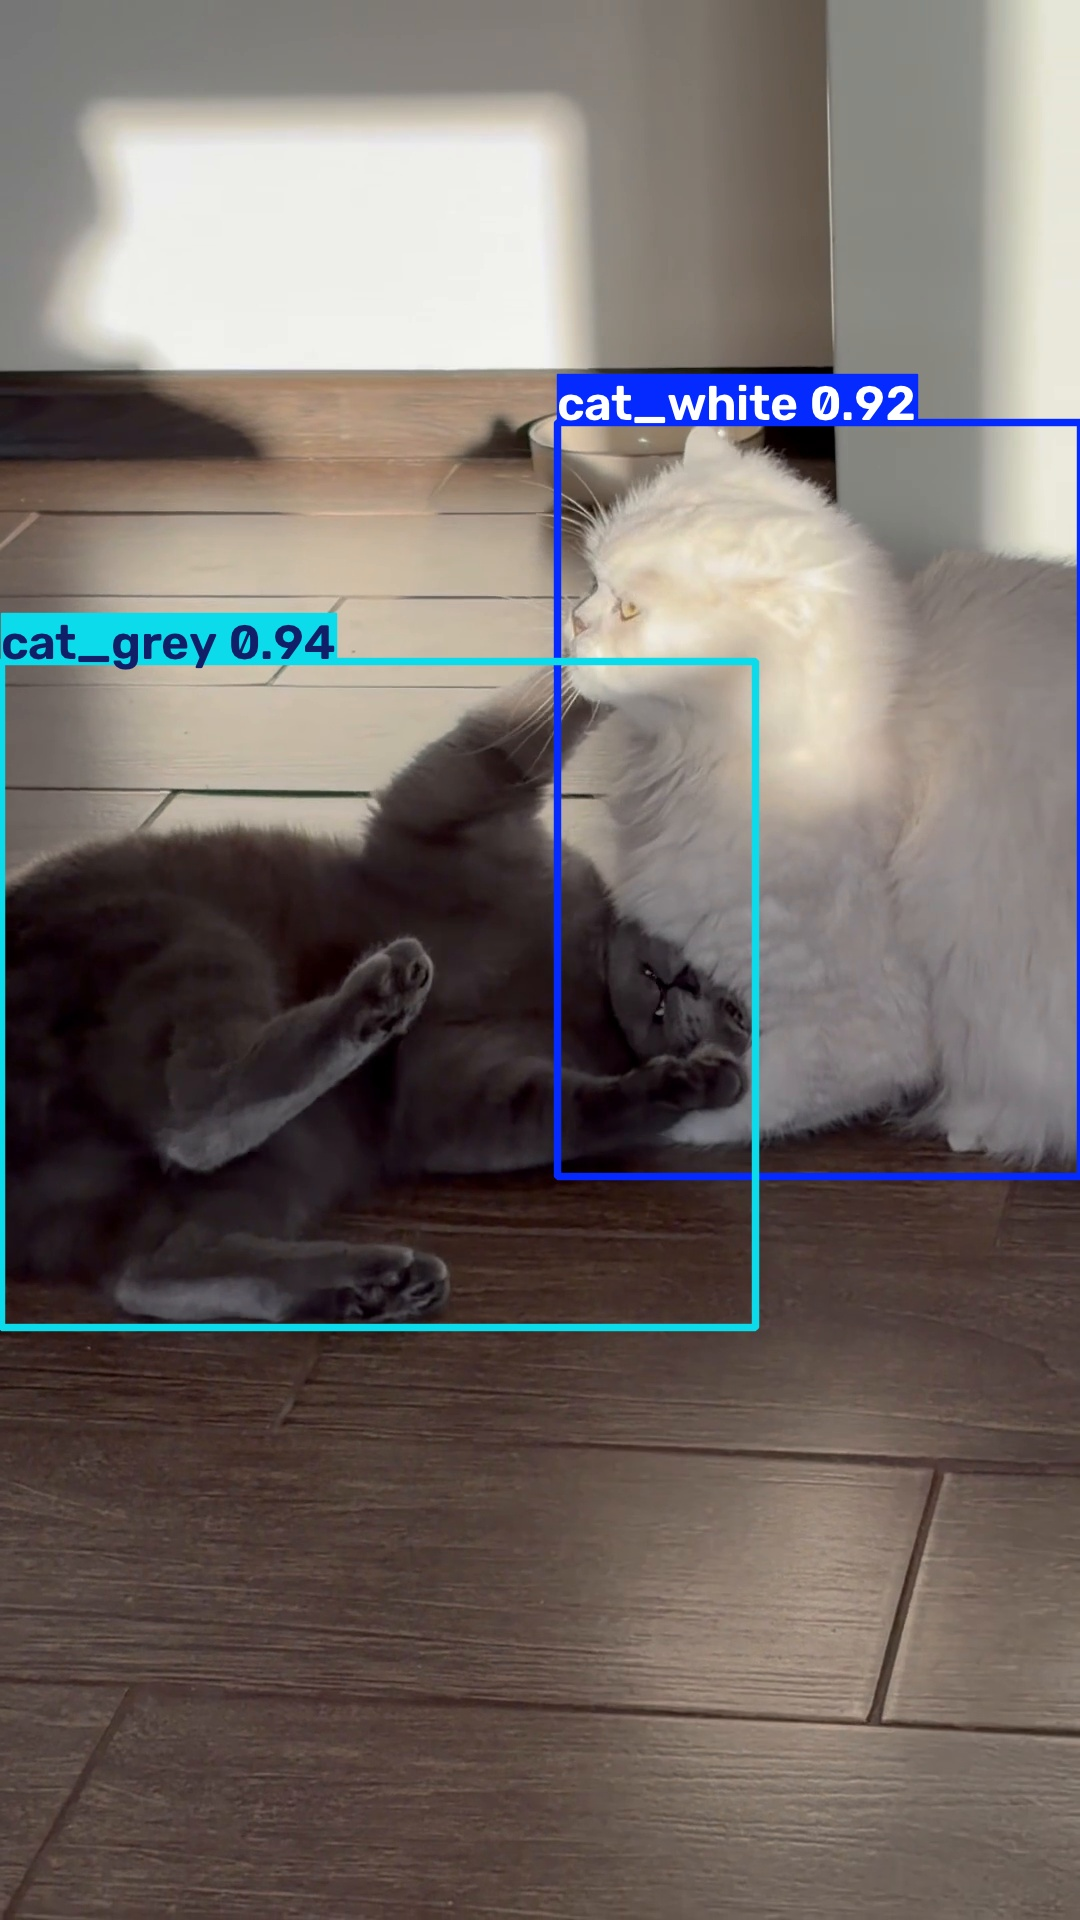

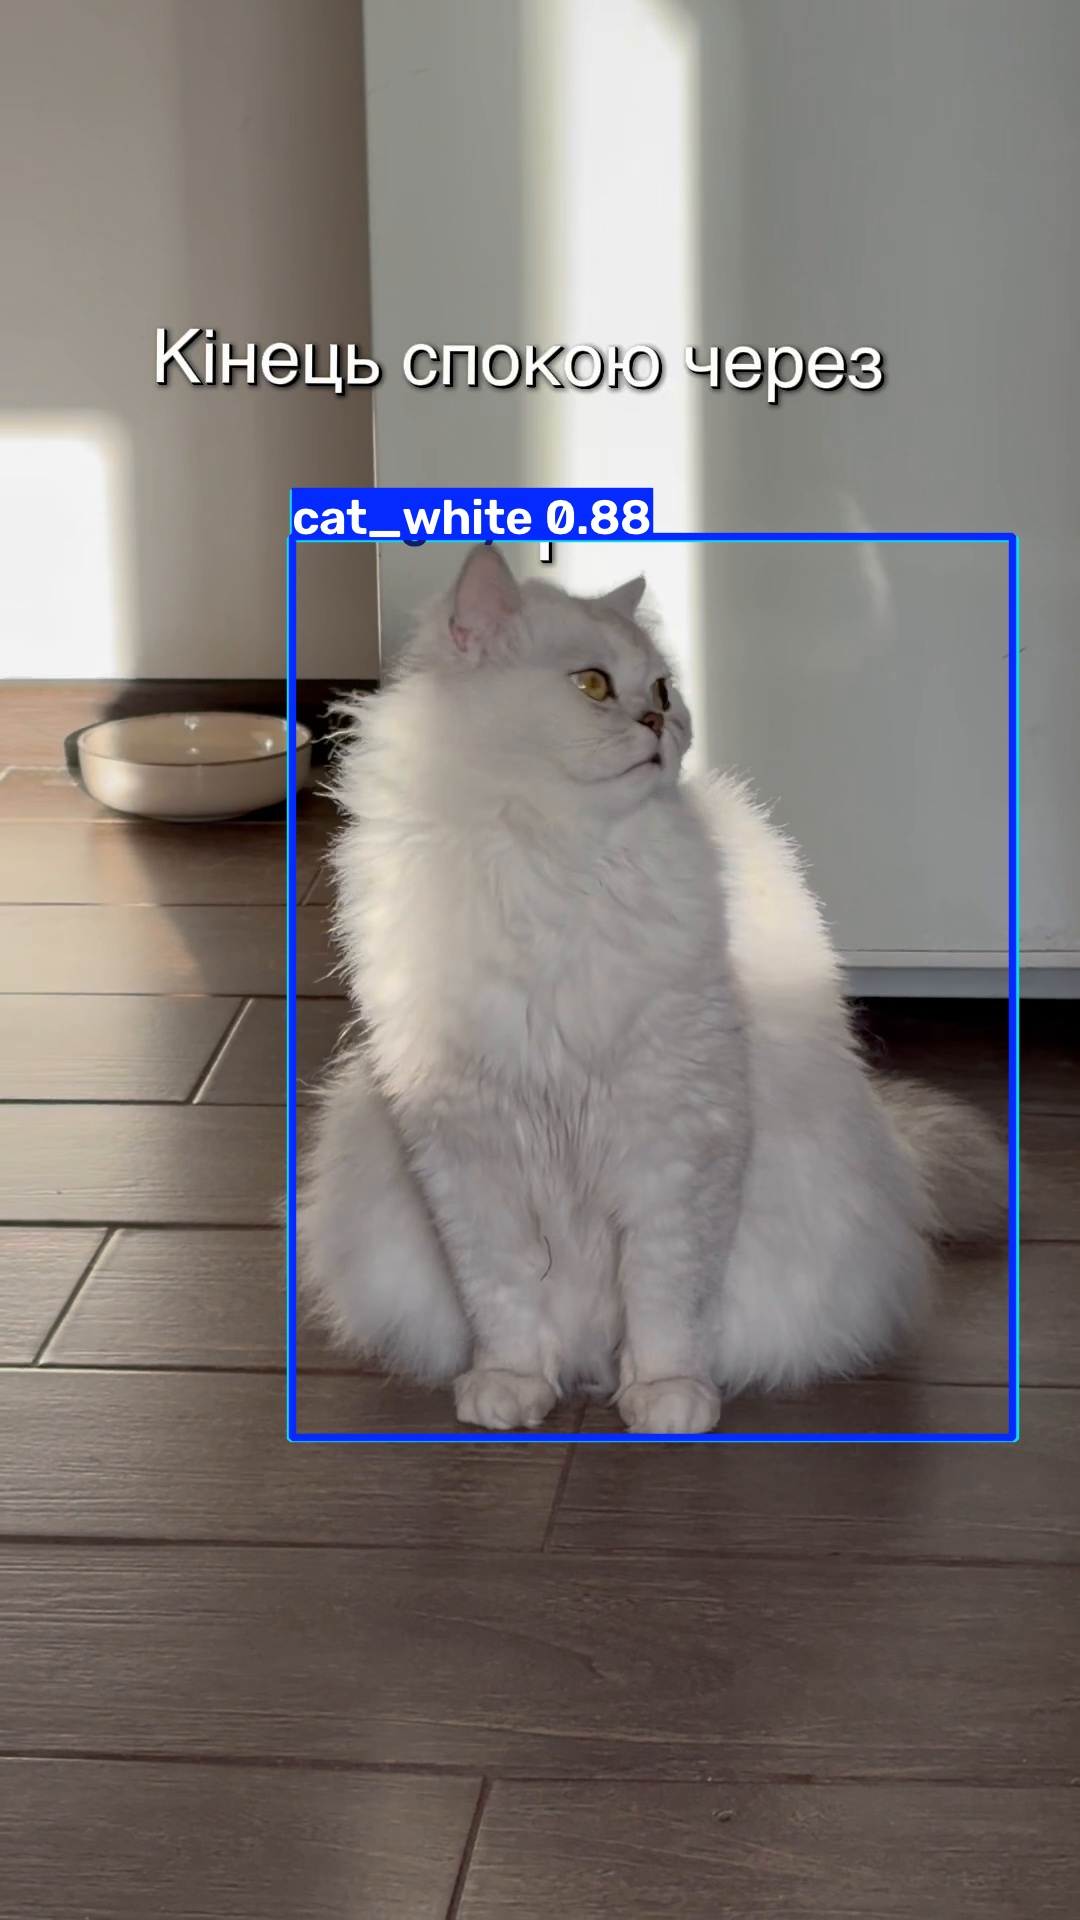

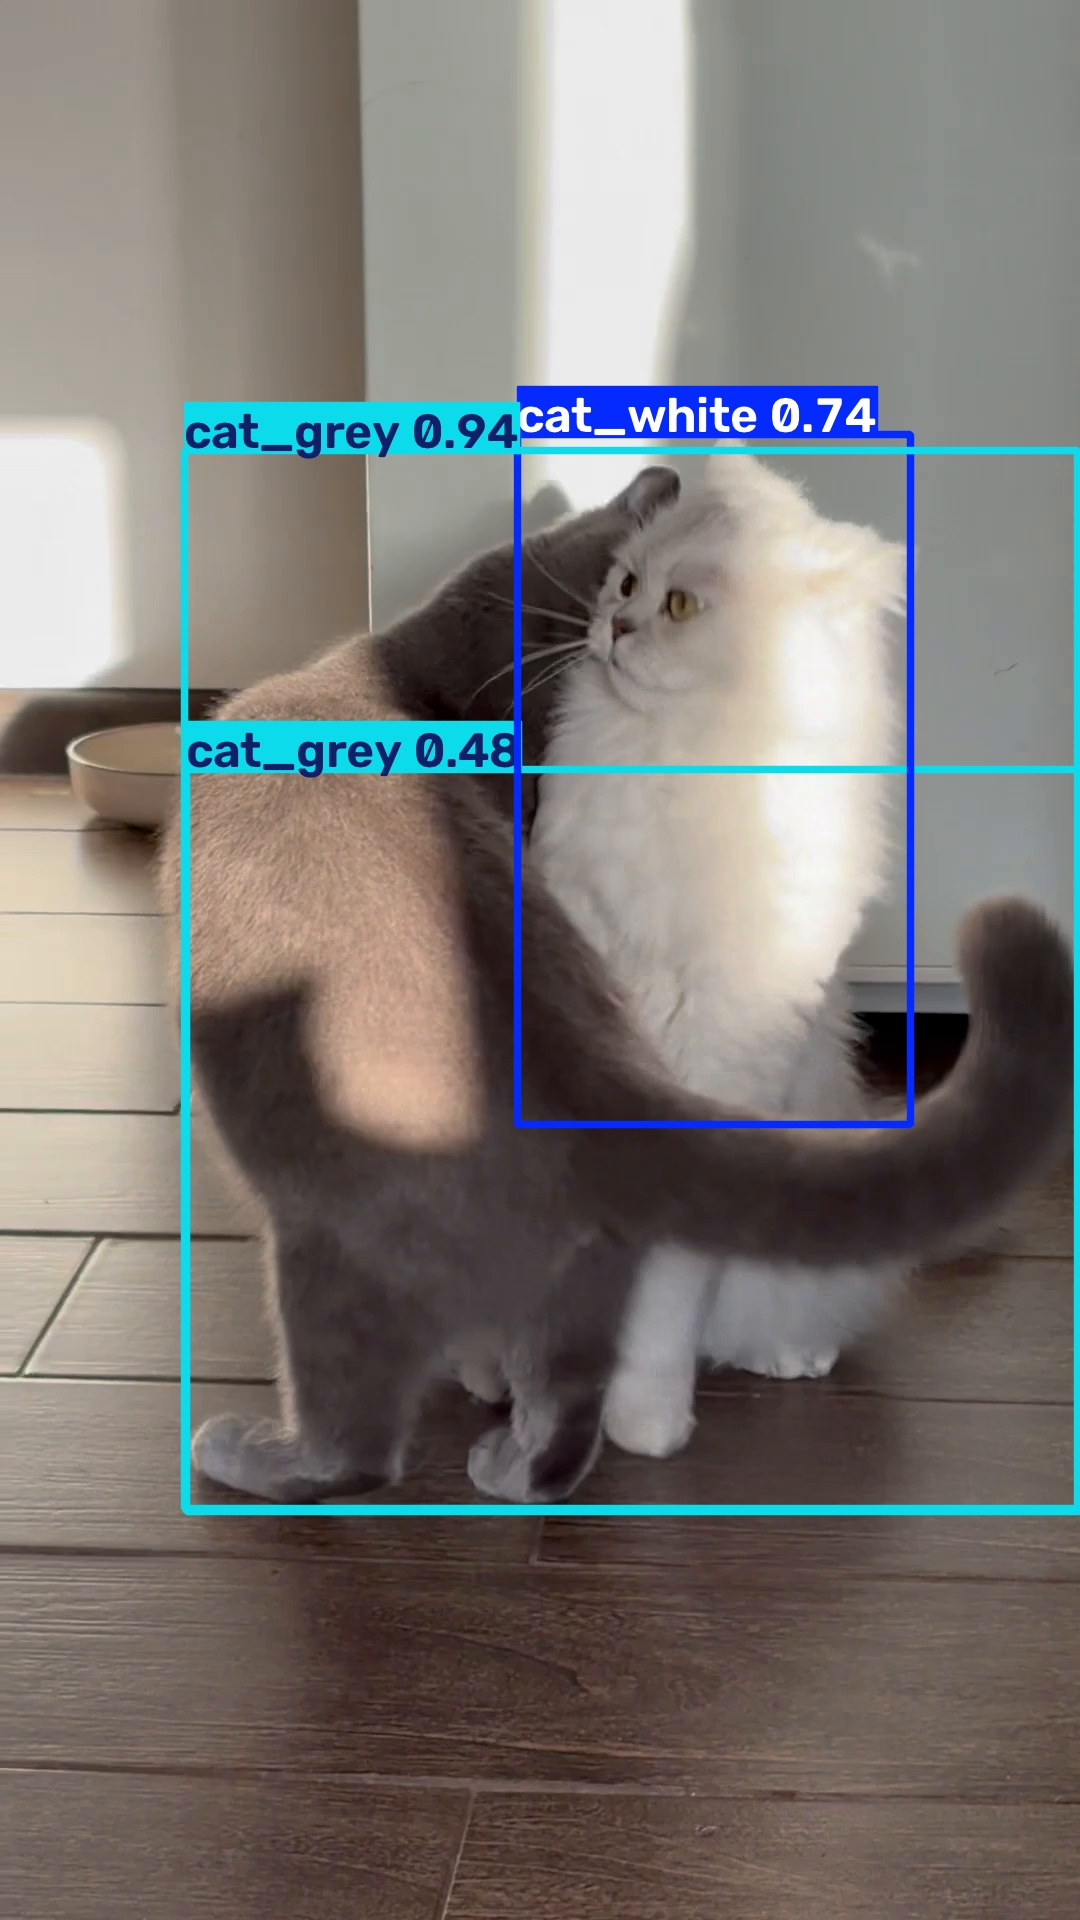

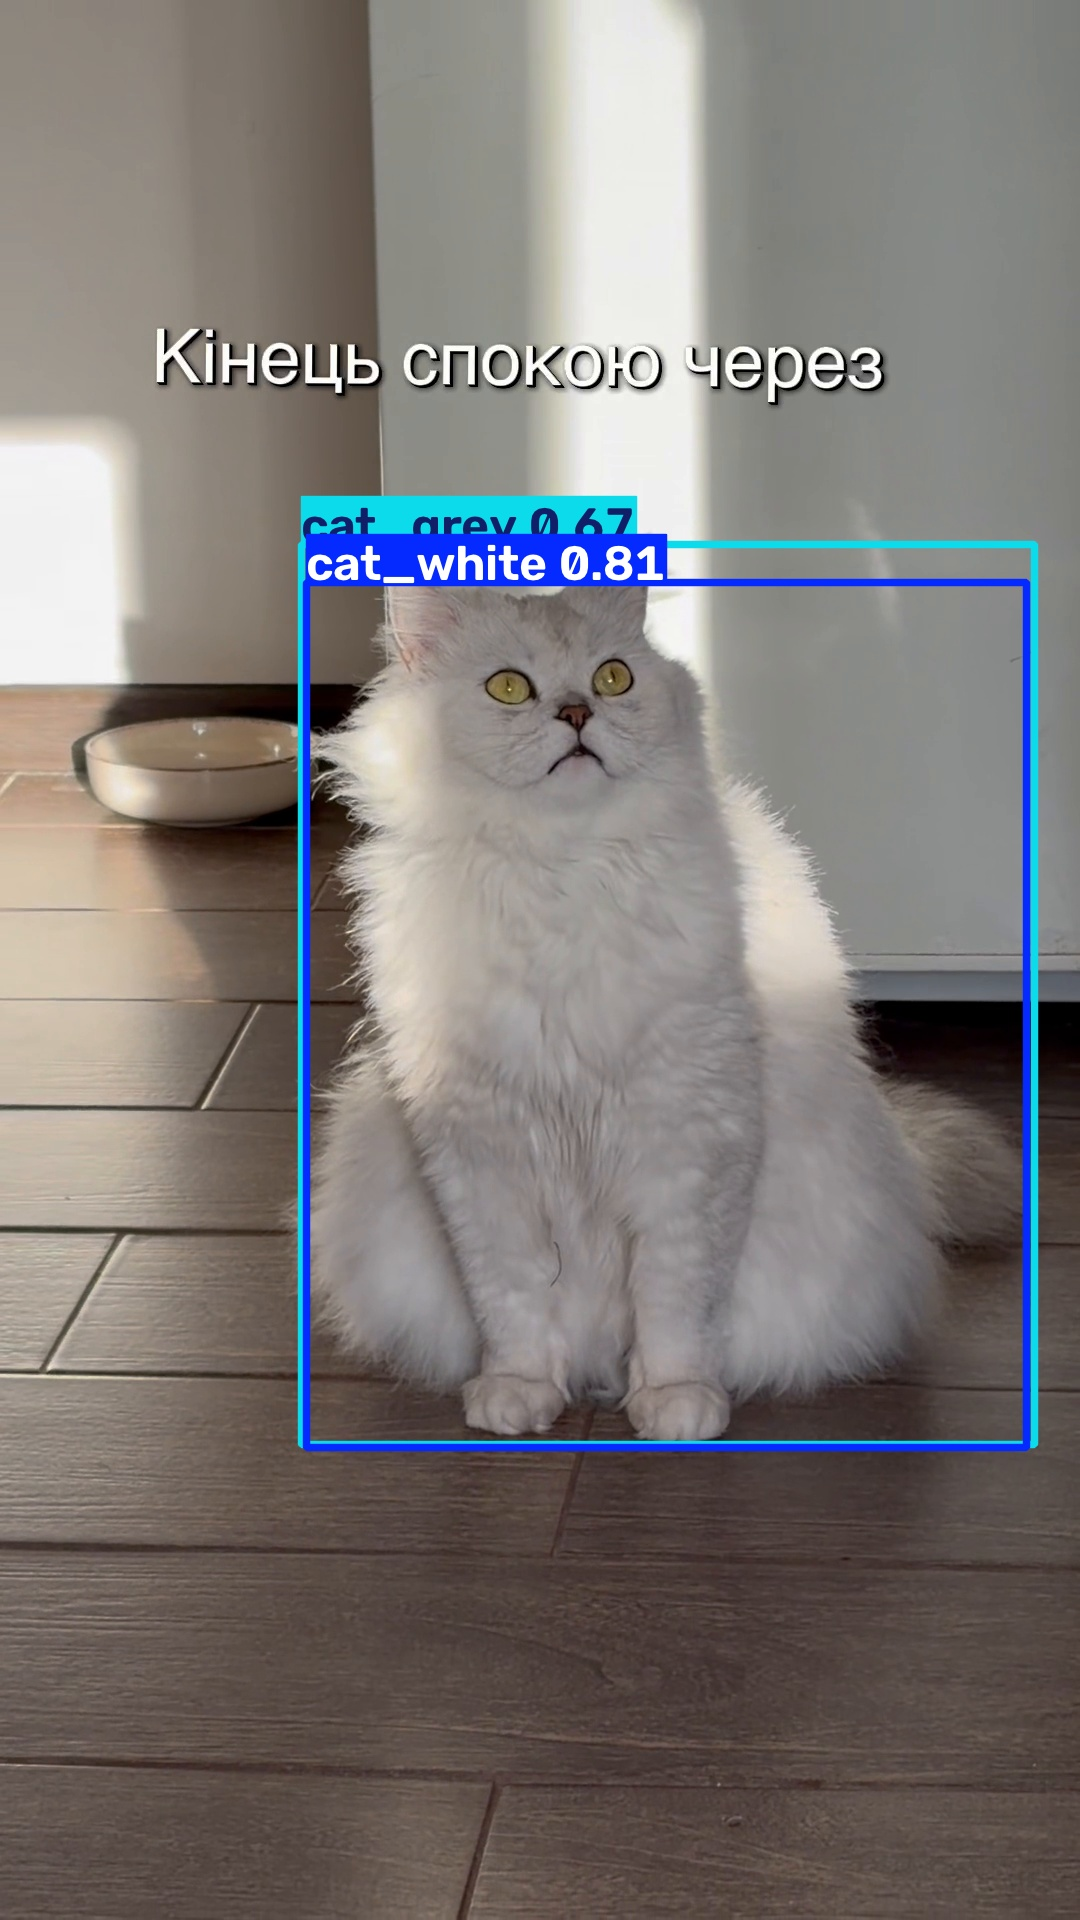

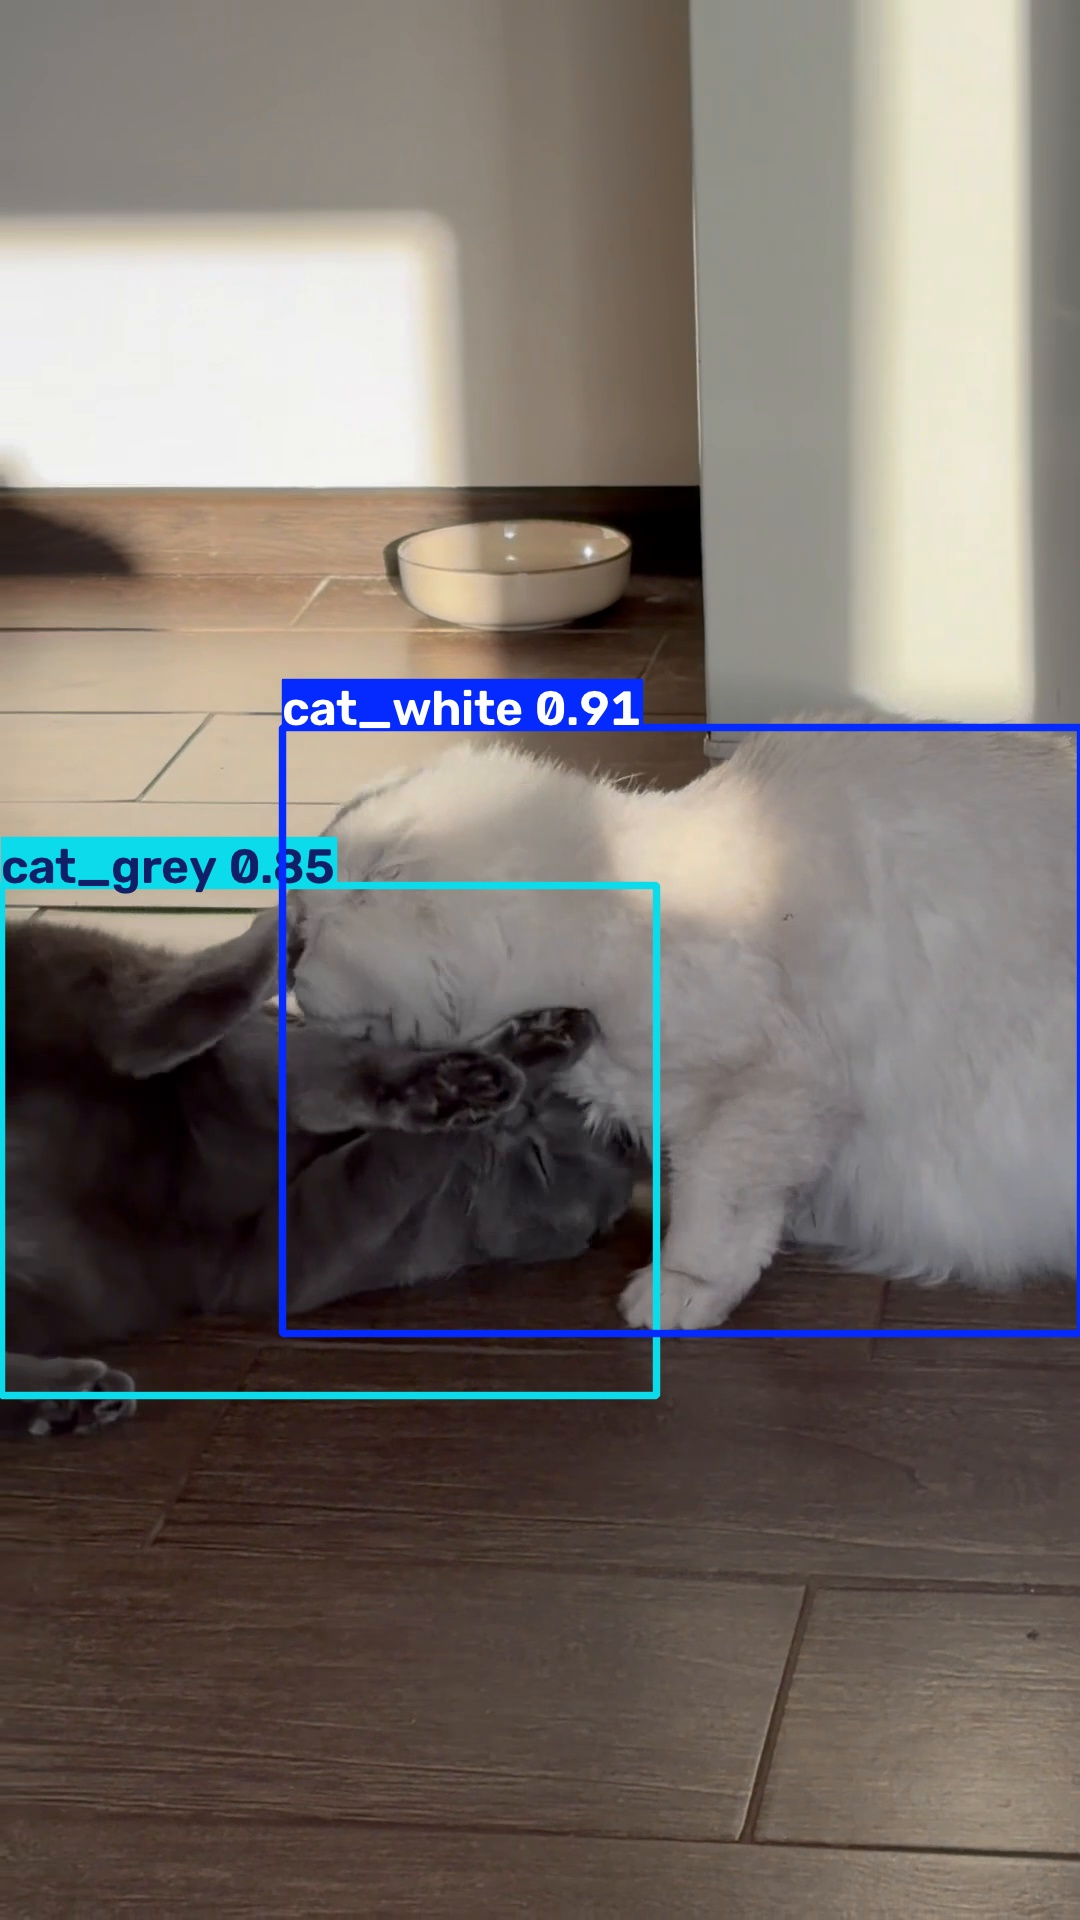

In [19]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'runs/detect/cat-fight-detector-3/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')